# One-Dimensional Time Dependent Heat Equation

Consider the following partial differential equation

$$
\frac{\partial U}{\partial T} = \kappa\frac{\partial^2U}{\partial X^2}\,,
$$

where $U\equiv U(X,T)\,,$ $\kappa$ is a constant, $T$ represents time and $X$ represents the spatial dimension. 
This PDE which is classified as parabolic.

It is known as the time dependent heat equation in one spatial dimension.
It is identical to the diffusion equation for the same "space-time" domain.

Provided the "boundary" conditions are specified this PDE can be solved analytically. In this example the we deal with initial conditions. As an example, consider, ...


The point of this example is, however, to learn how to solve such a PDE using numerical methods.

To this end let us write the above PDE in dimensionless form. Consider a spatial section of length $L$ and
define the dimensionless variable $x$ by

$$
x = \frac{X}{L}\,.$$

Furthermore, let $u = U/U_0\,,$ where $U_0$ is some particular value for $U\,,$ e.g. its maximum or minimum at $T = 0\,.$

Now, by the Chain Rule

$$
\frac{\partial U}{\partial X} = \frac{\partial U}{\partial x}\frac{dx}{dX} = \frac{1}{L}\frac{\partial U}{\partial x}\,.
$$

And it follows that 

$$
\frac{\partial^2 U}{\partial X^2} = \frac{\partial\,}{\partial X}\left(\frac{\partial U}{\partial X}\right) = \frac{dx}{dX}\frac{\partial\,}{\partial x}\left(\frac{1}{L}\frac{\partial U}{\partial x}\right) = \frac{1}{L^2}\frac{\partial^2 U}{\partial x^2}\,.
$$

Thus we can wrtie

$$
\frac{\partial U}{\partial T} = \frac{\kappa}{L^2}\frac{\partial^2U}{\partial x^2}\,.
$$

Defining the following dimensionless time variable by 

$$
t = \frac{\kappa T}{L^2}
$$

we get

$$
\frac{\partial U}{\partial t} = \frac{\partial^2U}{\partial x^2}\,.
$$

Since $U = uU_0$ the dimensionless form of the PDE under consideration is


$$
\frac{\partial u}{\partial t} = \frac{\partial^2u}{\partial x^2}\,.
$$

To solve this equation numerically we are going to implement the methods of finite differences. There are a few different ways to do so.

## Case 1 (Explicit Method)

To solve this using finite differences we approximate the first partial time derivative of $u(x,t)$ as follows. Consider the $\textit{forward difference method}$ whereby

$$
\frac{\partial u}{\partial t} \approx \frac{u(x_i,t_{j+1}) - u(x_i,t_j)}{t_{j+1} - t_{j}} = \frac{u_{i,j+1} - u_{i,j}}{t_{j+1} - t_{j}}\,,
$$

where the spatial interval has been divided up into a grid of points and the temporal interval has been also. The index $i$ is
for the spatial interval and the index $j$ is for the temporal interval.

Letting $k = t_{j+1} - t_{j}\,,$ where $t_j = jk\,, (j = 1, 2, 3, ...)\,,$ we can write

$$
\frac{\partial u}{\partial t} \approx \frac{u_{i,j+1} - u_{i,j}}{k}\,.
$$

To handle the spatial derivatives, we fix the time and evaluate the derivative using $u_{i,j}\,, u_{i+1,j}\,,$ and $u_{i-1,j}\,.$

The first spatial derivative at a point ${i,j}$ can be approximated by using the $\textit{forward difference method}$ 

$$
\frac{\partial u}{\partial x} \approx \frac{u_{i+1,j} - u_{i,j}}{h}\,,
$$

where $h = x_{i+1} - x_{i}$ because $x_i = ih\,, i = 1, 2, 3,\ldots\,.$ It can also be approximated using the $\textit{backward difference method}$

$$
\frac{\partial u}{\partial x} \approx \frac{u_{i,j} - u_{i-1,j}}{h}\,.
$$

To obtain the second spatial derivative consider a Taylor series expansion of $u(x+h,t)$ at fixed time. To second order this is given by

$$
u(x+h,t) = u(x,t) + hu^{\prime}(x,t) + \frac{1}{2!}h^2u^{\prime\prime}(x,t) + {\cal O}(h^3)\,.
$$

Consider also the Taylor expansion of $u(x-h,t)$ at fixed time. This is given by

$$
u(x-h,t) = u(x,t) - hu^{\prime}(x,t) + \frac{1}{2!}h^2u^{\prime\prime}(x,t) + {\cal O}(h^3)\,.
$$

Therefore, we can approximate $u^{\prime\prime}(x,t)$ by

$$
u^{\prime\prime}(x,t) \simeq \frac{2!}{2h^2}\left(u(x+h,t) - 2u(x,t) + u(x-h,t)\right)\,.
$$

From this, the second partial derivative at a point $(x_i,t_j)$ is estimated to be

$$
\frac{\partial^2u(x,t)}{\partial x^2} \simeq \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{h^2}\,.
$$

Consequently,

$$
(u_{i,j+1} - u_{i,j}) = \frac{k}{h^2}(u_{i+1,j} - 2u_{i,j} + u_{i-1,j})\,.
$$

Defining $r$ by $r = k/h^2$ we have

$$
u_{i,j+1} = ru_{i+1,j} + (1 - 2r)u_{i,j} + ru_{i-1,j}\,.
$$

This ''is a formula for unknown 'temperature' $u_{i,j+1}$ at the (i,j+1)th mesh point in terms of the known 'temperatures' along the jth time-row." This means that "the unknown pivotal values of $u$ along the first time-row, $t=k$," can be calculated in terms of known boundary and initial values a along $t=0\,,$ and then the unknown pivotal values along the second time-row in terms of the first, and so on.

So we have explicit formula to do this.

### Example 2.1 from <cite id="czxfj"><a href="#zotero%7C23985153%2FLZRBF4QU">(Smith, 1978)</a></cite>

Consider a rod whose ends are kept in contact with blocks of melting ice and whose initial temperature distribution is given given in non-dimensional form by

$$
u(x,0) =
\begin{cases}
2x\,& 0\le x \le \frac{1}{2}\,,\\
2(1 -x)\,& \frac{1}{2}\le x\le 1\,.
\end{cases}
$$

Since the rod is kept in contact with the blocks of ice, this problem also has the boundary conditions $u(0,t) = 0 = u(1,t)\,,\forall\,\, t > 0\,.$

In [1]:
"""Specify a matrix containing the known an unknown values of u(x,t)"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sympy import Sum, Symbol

#%matplotlib notebook

In [2]:
N = 10 # space
M = 20 # time
u = np.zeros((N+1,M+1)) # The first index corresponds to space  and the second time.

In [3]:
h = 1.0e-1 # the step-size in x, delta x
k = 1.0e-3 # the step-size in t, delta t
tf = k*(M)

r = np.round((k/h)/h,1)
print(r)

x = np.linspace(0,1,N+1)
t = np.linspace(0,tf,M+1)

0.1


In [4]:
print(x)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [5]:
print(t)

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]


In [6]:
for j in range(1,M+1):
    u[0,j] = 0 # bc; boundary condition
    u[N,j] = 0 # bc; boundary condition 

In [7]:
u

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.,

In [8]:
# ic; initial conditions
for i in range(0,5):
    u[i,0] = 2*i*h

for i in range(5,N+1):
    u[i,0] = 2.*(1 - i*h)

In [9]:
print(u)

[[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.2 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.4 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.6 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.8 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.8 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.6 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.4 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.2 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. ]]


In [10]:
for j in range(0,M):
    for i in range(1,N):
        u[i,j+1] = r*u[i+1,j] + (1-2*r)*u[i,j] + r*u[i-1,j]

In [11]:
print(u)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.2        0.2        0.2        0.2        0.2        0.199996
  0.19998    0.1999414  0.1998686  0.19975032 0.19957651 0.19933888
  0.1990311  0.19864883 0.19818957 0.19765246 0.197038   0.19634784
  0.19558451 0.1947512  0.19385161]
 [0.4        0.4        0.4        0.4        0.39996    0.399832
  0.399574   0.3991548  0.3985544  0.39776254 0.39677667 0.39559995
  0.39423951 0.39270511 0.39100803 0.38916036 0.38717441 0.38506235
  0.38283595 0.38050646 0.37808446]
 [0.6        0.6        0.6        0.5996     0.59864    0.597088
  0.594976   0.5923642  0.58932161 0.58591607 0.5822096  0.57825666
  0.57410387 0.56979061 0.56534978 0.56080875 0.55619019 0.5515129
  0.54679245 0.54204173 0.53727148]
 [0.8        0.8        0.796      0.7896     0.7818     0.773224
  0.7

In [12]:
u[0,:]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [13]:
import pandas as pd

In [14]:
u_transpose = np.transpose(u)
u_transpose

array([[0.        , 0.2       , 0.4       , 0.6       , 0.8       ,
        1.        , 0.8       , 0.6       , 0.4       , 0.2       ,
        0.        ],
       [0.        , 0.2       , 0.4       , 0.6       , 0.8       ,
        0.96      , 0.8       , 0.6       , 0.4       , 0.2       ,
        0.        ],
       [0.        , 0.2       , 0.4       , 0.6       , 0.796     ,
        0.928     , 0.796     , 0.6       , 0.4       , 0.2       ,
        0.        ],
       [0.        , 0.2       , 0.4       , 0.5996    , 0.7896    ,
        0.9016    , 0.7896    , 0.5996    , 0.4       , 0.2       ,
        0.        ],
       [0.        , 0.2       , 0.39996   , 0.59864   , 0.7818    ,
        0.8792    , 0.7818    , 0.59864   , 0.39996   , 0.2       ,
        0.        ],
       [0.        , 0.199996  , 0.399832  , 0.597088  , 0.773224  ,
        0.85972   , 0.773224  , 0.597088  , 0.399832  , 0.199996  ,
        0.        ],
       [0.        , 0.19998   , 0.399574  , 0.594976  , 0.

In [15]:
cols = []
for i in range(11):
    cols.append(str(np.round(x[i],1)))
    cols[i] = 'x = ' + cols[i]

In [16]:
times = []
for j in range(21):
    times.append(str(np.round(t[j],3)))
    times[j] = 't = ' + times[j] + ' (j = ' + str(j)+')'
times

['t = 0.0 (j = 0)',
 't = 0.001 (j = 1)',
 't = 0.002 (j = 2)',
 't = 0.003 (j = 3)',
 't = 0.004 (j = 4)',
 't = 0.005 (j = 5)',
 't = 0.006 (j = 6)',
 't = 0.007 (j = 7)',
 't = 0.008 (j = 8)',
 't = 0.009 (j = 9)',
 't = 0.01 (j = 10)',
 't = 0.011 (j = 11)',
 't = 0.012 (j = 12)',
 't = 0.013 (j = 13)',
 't = 0.014 (j = 14)',
 't = 0.015 (j = 15)',
 't = 0.016 (j = 16)',
 't = 0.017 (j = 17)',
 't = 0.018 (j = 18)',
 't = 0.019 (j = 19)',
 't = 0.02 (j = 20)']

In [17]:
u_numeric = pd.DataFrame(u_transpose, index = times, columns = cols)
u_numeric

,x = 0.0,x = 0.1,x = 0.2,x = 0.3,x = 0.4,x = 0.5,x = 0.6,x = 0.7,x = 0.8,x = 0.9,x = 1.0
t = 0.0 (j = 0),0.0,0.200000,0.400000,0.600000,0.800000,1.000000,0.800000,0.600000,0.400000,0.200000,0.0
t = 0.001 (j = 1),0.0,0.200000,0.400000,0.600000,0.800000,0.960000,0.800000,0.600000,0.400000,0.200000,0.0
t = 0.002 (j = 2),0.0,0.200000,0.400000,0.600000,0.796000,0.928000,0.796000,0.600000,0.400000,0.200000,0.0
t = 0.003 (j = 3),0.0,0.200000,0.400000,0.599600,0.789600,0.901600,0.789600,0.599600,0.400000,0.200000,0.0
t = 0.004 (j = 4),0.0,0.200000,0.399960,0.598640,0.781800,0.879200,0.781800,0.598640,0.399960,0.200000,0.0
t = 0.005 (j = 5),0.0,0.199996,0.399832,0.597088,0.773224,0.859720,0.773224,0.597088,0.399832,0.199996,0.0
t = 0.006 (j = 6),0.0,0.199980,0.399574,0.594976,0.764260,0.842421,0.764260,0.594976,0.399574,0.199980,0.0
t = 0.007 (j = 7),0.0,0.199941,0.399155,0.592364,0.755148,0.826789,0.755148,0.592364,0.399155,0.199941,0.0
t = 0.008 (j = 8),0.0,0.199869,0.398554,0.589322,0.746033,0.812460,0.746033,0.589322,0.398554,0.199869,0.0
t = 0.009 (j = 9),0.0,0.199750,0.397763,0.585916,0.737005,0.799175,0.737005,0.585916,0.397763,0.199750,0.0


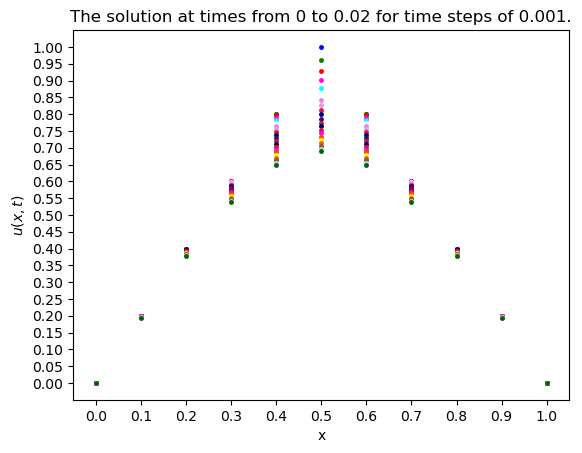

In [18]:
c =['blue','green','red','magenta','aqua','azure','violet','plum','crimson',
    'darkblue','indigo','brown','navy','crimson','fuchsia','orangered','yellow',
   'chocolate','sienna','lightblue','darkgreen']

uticks = np.linspace(0,1,21)
for i in range(0,N+1):
    for j in range(0,M+1):
        plt.plot(x[i],u[i,j],'.',color = c[j],markersize=5.0) # plot starts at blue
        # finishes at darkgreen (t = 0.02 s)
        plt.xlabel(r'x')
        plt.ylabel(r'$u(x,t)$')
        plt.xticks(x)
        plt.yticks(uticks)
        plt.title("The solution at times from 0 to 0.02 for \
time steps of 0.001.")
        #plt.gca().set_aspect('equal')

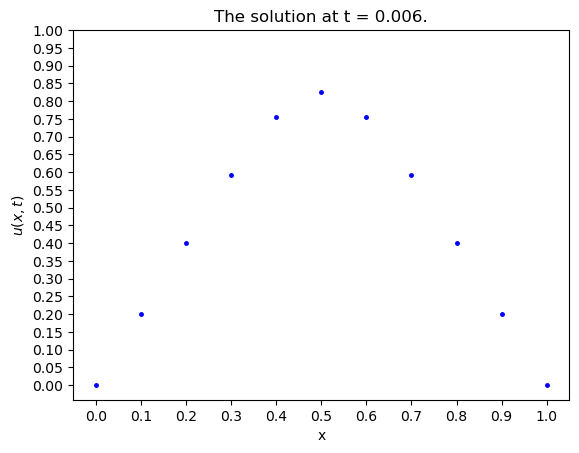

In [19]:
plt.plot(x[:],u[:,7],'.',color = 'b',markersize=5.0)
plt.xlabel(r'x')
plt.ylabel(r'$u(x,t)$')
plt.xticks(x)
plt.yticks(uticks)
plt.title("The solution at t = 0.006.")
plt.show()

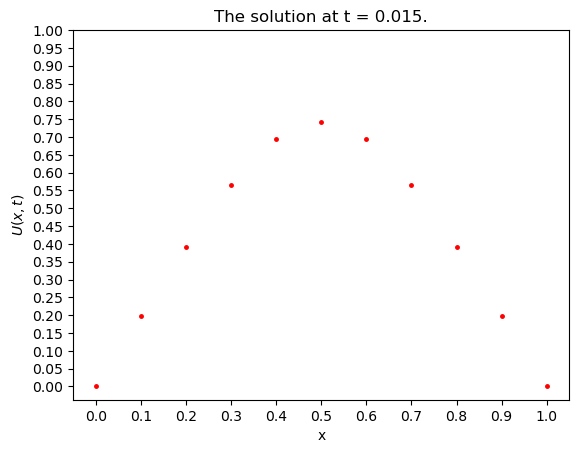

In [20]:
plt.plot(x[:],u[:,14],'.',color = 'r',markersize=5.0) # plot starts at blue
# finishes at darkgreen (t = 0.02 s)
plt.xlabel(r'x')
plt.ylabel(r'$U(x,t)$')
plt.xticks(x)
plt.yticks(uticks)
plt.title("The solution at t = 0.015.")
plt.show()

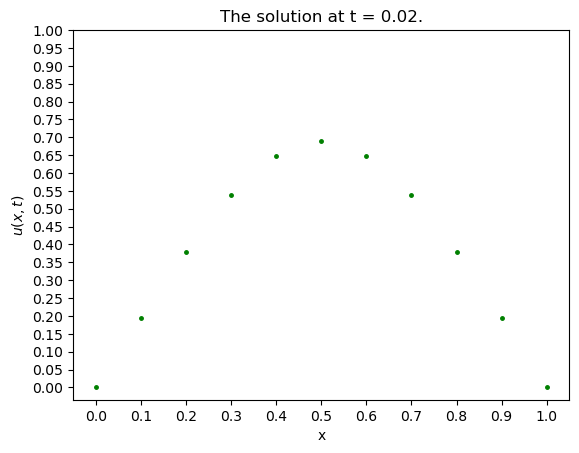

In [21]:
plt.plot(x[:],u[:,20],'.',color = 'g',markersize=5.0) # plot starts at blue
# finishes at darkgreen (t = 0.02 s)
plt.xlabel(r'x')
plt.ylabel(r'$u(x,t)$')
plt.xticks(x)
plt.yticks(uticks)
plt.title("The solution at t = 0.02.")
plt.show()

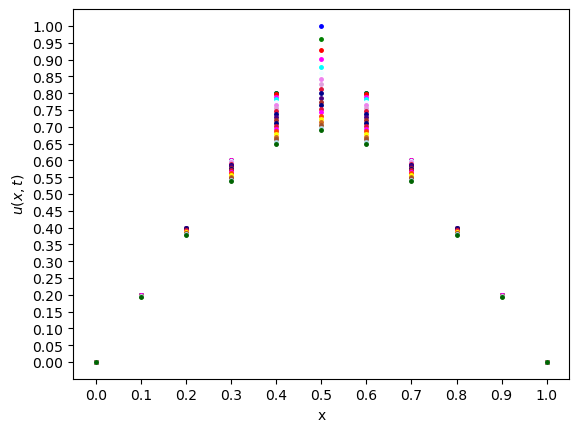

In [22]:
for j in range(0,M+1):
    plt.plot(x[:],u[:,j],'.',color = c[j],markersize=5.0) # plot starts at blue
    # finishes at darkgreen (t = 0.02 s)
    plt.xlabel(r'x')
    plt.ylabel(r'$u(x,t)$')
    plt.xticks(x)
    plt.yticks(uticks)
    #plt.gca().set_aspect('equal')

The analytical solution to the partial differential equation

$$
\frac{\partial u}{\partial t} = \frac{\partial^2u}{\partial t^2}
$$

for the boundary conditions $u = 0$ when $x=0$ and $x=1$ for all $t$, and the initial condition
$$
u(x,t=0) =
\begin{cases}
2x,\, 0\le x\le \frac{1}{2}\\[4mm]
2(1-x),\, \frac{1}{2}\le x\le 1\,,
\end{cases}
$$

is

$$
u(x,t) = \frac{8}{\pi^2}\displaystyle\sum_{m=1}^{\infty}\frac{1}{m^2}\sin\left(\frac{m\pi}{2}\right)\sin(m\pi x)e^{-m^2\pi^2t}\,.
$$


In [23]:
import mpmath as mp

In [24]:
def u_analytic(x,t,n):
    s = 0
    for m in range(1,n+1,1):
        s += 1/m**2*np.sin(np.pi*m/2)*np.sin(m*np.pi*x)*np.exp(-(m*np.pi)**2*t)
    return (8/np.pi**2)*s

# def u_analytic(x,t,N):
#     s = 0
#     s_term = 1/n**2*np.sin(np.pi*n/2)*np.sin(n*np.pi*x)*np.exp(-(n*np.pi)**2*t)
#     s = sum[s_term for n in range(1,N+1,1)]
#         #s += 1/n**2*np.sin(np.pi*n/2)*np.sin(n*np.pi*x)*np.exp(-(n*np.pi)**2*t)
#     return (8/np.pi**2)*s

In [25]:
u_analytic(0.3, 0.005,10000)

0.5966037189532682

In [26]:
u_analytic(0.3, 0.005,100000)

0.5966037189532682

In [27]:
x_space_points = np.linspace(0,1,10000)

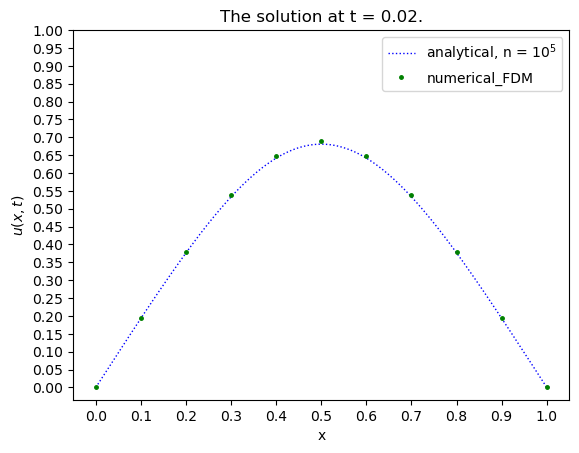

In [28]:
plt.plot(x_space_points,u_analytic(x_space_points,0.02,100000),color='b', ls = ':', lw = 1.0, label = r'analytical, n = 10$^5$')
plt.plot(x[:],u[:,20],'.',color = 'g',markersize=5.0, label = r'numerical_FDM') # plot starts at blue
# finishes at darkgreen (t = 0.02 s)
plt.xlabel(r'x')
plt.ylabel(r'$u(x,t)$')
plt.xticks(x)
plt.yticks(uticks)
plt.title("The solution at t = 0.02.")
plt.legend()
plt.show()

In [29]:
np.round(u_analytic(0.3,0.005,100000),4)

0.5966

In [30]:
np.round(u[3,5],4)

0.5971

In [31]:
N = 10 # space
M_new = 100 # time
u_new = np.zeros((N+1,M_new+1)) # The first index corresponds to space  and the second time.

h = 1.0e-1 # the step-size in x, delta x
k = 1.0e-3 # the step-size in t, delta t
tf = k*(M_new)

r = np.round((k/h)/h,1)

x_new = np.linspace(0,1,N+1)
t_new = np.linspace(0,tf,M_new+1)

for j in range(1,M_new+1):
    u_new[0,j] = 0 # bc; boundary condition
    u_new[N,j] = 0 # bc; boundary condition 

In [32]:
print(u_new)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [33]:
# ic; initial conditions
for i in range(0,5):
    u_new[i,0] = 2*i*h

for i in range(5,N+1):
    u_new[i,0] = 2.*(1 - i*h)

In [34]:
print(u_new)

[[0.  0.  0.  ... 0.  0.  0. ]
 [0.2 0.  0.  ... 0.  0.  0. ]
 [0.4 0.  0.  ... 0.  0.  0. ]
 ...
 [0.4 0.  0.  ... 0.  0.  0. ]
 [0.2 0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]]


In [35]:
for j in range(0,M_new):
    for i in range(1,N):
        u_new[i,j+1] = r*u_new[i+1,j] + (1-2*r)*u_new[i,j] + r*u_new[i-1,j]

In [36]:
u_new_transpose = np.transpose(u_new)
u_new_transpose

array([[0.        , 0.2       , 0.4       , ..., 0.4       , 0.2       ,
        0.        ],
       [0.        , 0.2       , 0.4       , ..., 0.4       , 0.2       ,
        0.        ],
       [0.        , 0.2       , 0.4       , ..., 0.4       , 0.2       ,
        0.        ],
       ...,
       [0.        , 0.09629474, 0.1831759 , ..., 0.1831759 , 0.09629474,
        0.        ],
       [0.        , 0.09535338, 0.18138431, ..., 0.18138431, 0.09535338,
        0.        ],
       [0.        , 0.09442114, 0.17961013, ..., 0.17961013, 0.09442114,
        0.        ]])

In [37]:
new_times = []
for j in range(101):
    new_times.append(str(np.round(t_new[j],3)))
    new_times[j] = 't = ' + new_times[j] + ' (j = ' + str(j)+')'
new_times

['t = 0.0 (j = 0)',
 't = 0.001 (j = 1)',
 't = 0.002 (j = 2)',
 't = 0.003 (j = 3)',
 't = 0.004 (j = 4)',
 't = 0.005 (j = 5)',
 't = 0.006 (j = 6)',
 't = 0.007 (j = 7)',
 't = 0.008 (j = 8)',
 't = 0.009 (j = 9)',
 't = 0.01 (j = 10)',
 't = 0.011 (j = 11)',
 't = 0.012 (j = 12)',
 't = 0.013 (j = 13)',
 't = 0.014 (j = 14)',
 't = 0.015 (j = 15)',
 't = 0.016 (j = 16)',
 't = 0.017 (j = 17)',
 't = 0.018 (j = 18)',
 't = 0.019 (j = 19)',
 't = 0.02 (j = 20)',
 't = 0.021 (j = 21)',
 't = 0.022 (j = 22)',
 't = 0.023 (j = 23)',
 't = 0.024 (j = 24)',
 't = 0.025 (j = 25)',
 't = 0.026 (j = 26)',
 't = 0.027 (j = 27)',
 't = 0.028 (j = 28)',
 't = 0.029 (j = 29)',
 't = 0.03 (j = 30)',
 't = 0.031 (j = 31)',
 't = 0.032 (j = 32)',
 't = 0.033 (j = 33)',
 't = 0.034 (j = 34)',
 't = 0.035 (j = 35)',
 't = 0.036 (j = 36)',
 't = 0.037 (j = 37)',
 't = 0.038 (j = 38)',
 't = 0.039 (j = 39)',
 't = 0.04 (j = 40)',
 't = 0.041 (j = 41)',
 't = 0.042 (j = 42)',
 't = 0.043 (j = 43)',
 't 

In [38]:
u_new_numeric = pd.DataFrame(u_new_transpose, index = new_times, columns = cols)
u_new_numeric

,x = 0.0,x = 0.1,x = 0.2,x = 0.3,x = 0.4,x = 0.5,x = 0.6,x = 0.7,x = 0.8,x = 0.9,x = 1.0
t = 0.0 (j = 0),0.0,0.200000,0.400000,0.600000,0.800000,1.000000,0.800000,0.600000,0.400000,0.200000,0.0
t = 0.001 (j = 1),0.0,0.200000,0.400000,0.600000,0.800000,0.960000,0.800000,0.600000,0.400000,0.200000,0.0
t = 0.002 (j = 2),0.0,0.200000,0.400000,0.600000,0.796000,0.928000,0.796000,0.600000,0.400000,0.200000,0.0
t = 0.003 (j = 3),0.0,0.200000,0.400000,0.599600,0.789600,0.901600,0.789600,0.599600,0.400000,0.200000,0.0
t = 0.004 (j = 4),0.0,0.200000,0.399960,0.598640,0.781800,0.879200,0.781800,0.598640,0.399960,0.200000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
t = 0.096 (j = 96),0.0,0.098205,0.186812,0.257150,0.302322,0.317889,0.302322,0.257150,0.186812,0.098205,0.0
t = 0.097 (j = 97),0.0,0.097245,0.184985,0.254633,0.299361,0.314776,0.299361,0.254633,0.184985,0.097245,0.0
t = 0.098 (j = 98),0.0,0.096295,0.183176,0.252141,0.296430,0.311693,0.296430,0.252141,0.183176,0.096295,0.0
t = 0.099 (j = 99),0.0,0.095353,0.181384,0.249673,0.293527,0.308640,0.293527,0.249673,0.181384,0.095353,0.0


In [39]:
data = {"time_data":["t = 0.005", "t = 0.01", "t = 0.02", "t = 0.10"], \
        "Finite-Difference solution (x = 0.3)":[np.round(u_new[3,5],4), np.round(u_new[3,10],4), \
        np.round(u_new[3,20],4), np.round(u_new[3,100],4)], \
        "Analytical result (x = 0.3)":[np.round(u_analytic(0.3,0.005,100000),4),\
                    np.round(u_analytic(0.3,0.01,100000),4),\
                    np.round(u_analytic(0.3,0.02,100000),4),\
                    np.round(u_analytic(0.3,0.10,100000),4)]}

In [40]:
anaylsis_df = pd.DataFrame(data)
anaylsis_df

,time_data,Finite-Difference solution (x = 0.3),Analytical result (x = 0.3)
0,t = 0.005,0.5971,0.5966
1,t = 0.01,0.5822,0.5799
2,t = 0.02,0.5373,0.5334
3,t = 0.10,0.2472,0.2444


<!-- BIBLIOGRAPHY START -->
<div class="csl-bib-body">
  <div class="csl-entry"><i id="zotero|23985153/LZRBF4QU"></i>Smith, G. D. (1978). <i>Numerical Solutions of Partial Differential Equations: Finite Difference Methods, 2nd Edition</i>. Clarendon Press, Oxford University Press,.</div>
</div>
<!-- BIBLIOGRAPHY END -->